In [1]:
import sys
!{sys.executable} -m pip install scikit-surprise

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader
from surprise import SVD, KNNBasic

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


### Load Datatset

In [21]:
data = pd.read_csv(
    'u.data',
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

print(data.head())
print("\nShape:", data.shape)

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Shape: (100000, 4)


In [22]:
print("Dataset Shape:", data.shape)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

Dataset Shape: (100000, 4)

Data Types:
user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

Missing Values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Duplicate Rows:
0


### Remove Duplicates

In [23]:
data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (100000, 4)


### Check Rating Distribution

In [24]:
print(data['rating'].value_counts().sort_index())

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


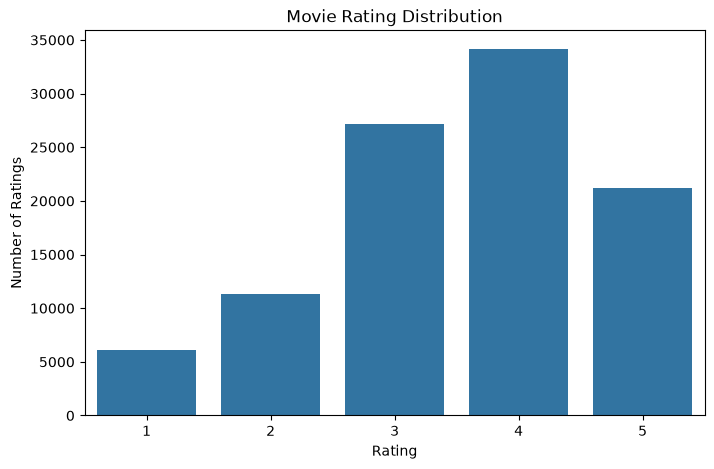

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='rating',
    data=data
)

plt.title('Movie Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')

plt.show()

### Create Classification Target

In [27]:
data['target'] = (data['rating'] >= 4).astype(int)

In [28]:
print(data[['rating', 'target']].head(20))

    rating  target
0        3       0
1        3       0
2        1       0
3        2       0
4        1       0
5        4       1
6        2       0
7        5       1
8        3       0
9        3       0
10       2       0
11       5       1
12       5       1
13       3       0
14       3       0
15       3       0
16       5       1
17       2       0
18       4       1
19       2       0


In [29]:
print(data['target'].value_counts())

print("\nPercentage:")
print(
    data['target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target
1    55375
0    44625
Name: count, dtype: int64

Percentage:
target
1    55.38
0    44.62
Name: proportion, dtype: float64


### Prepare Data

In [30]:
ratings = data[['user_id', 'movie_id', 'rating']].copy()

print(ratings.head())

   user_id  movie_id  rating
0      196       242       3
1      186       302       3
2       22       377       1
3      244        51       2
4      166       346       1


### 80/20 split

In [31]:
train_data, test_data = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print(
    "\nTraining percentage:",
    round(len(train_data) / len(ratings) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(test_data) / len(ratings) * 100, 2),
    "%"
)

Training records: 80000
Testing records: 20000

Training percentage: 80.0 %
Testing percentage: 20.0 %


## Prepare Data for Surprise

In [32]:
reader = Reader(
    rating_scale=(1, 5)
)

In [33]:
train_surprise = Dataset.load_from_df(
    train_data[['user_id', 'movie_id', 'rating']],
    reader
)

In [34]:
trainset = train_surprise.build_full_trainset()

### SVD Model

In [35]:
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [36]:
svd_model.fit(trainset)

### KNN Basic

In [37]:
knn_model = KNNBasic(
    k=40,
    min_k=1,
    sim_options={
        'name': 'cosine',
        'user_based': True
    }
)

In [38]:
knn_model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## SVD Predictions

In [39]:
svd_predictions = []

for row in test_data.itertuples():
    
    prediction = svd_model.predict(
        row.user_id,
        row.movie_id
    )
    
    svd_predictions.append(prediction.est)

In [40]:
svd_predictions = np.array(svd_predictions)

print("SVD predictions:")
print(svd_predictions[:10])

SVD predictions:
[3.77831143 3.84959711 3.1226774  2.9665561  4.26025937 3.29913298
 3.91692453 3.64151215 3.37878254 3.36051277]


## KNN Predictions

In [41]:
knn_predictions = []

for row in test_data.itertuples():
    
    prediction = knn_model.predict(
        row.user_id,
        row.movie_id
    )
    
    knn_predictions.append(prediction.est)

In [42]:
knn_predictions = np.array(knn_predictions)

print("KNN predictions:")
print(knn_predictions[:10])

KNN predictions:
[3.80011175 3.72427357 3.44820211 2.85155323 4.25075123 3.07667867
 4.         4.20063059 3.82687898 3.62414677]


### Convert Predictions into Classes

#### Actual classes

In [43]:
y_test = (
    test_data['rating'].values >= 4
).astype(int)

### SVD classes

In [44]:
y_pred_svd = (
    svd_predictions >= 4
).astype(int)

## KNN classes

In [45]:
y_pred_knn = (
    knn_predictions >= 4
).astype(int)

### SVD Evualuation

In [46]:
svd_accuracy = accuracy_score(
    y_test,
    y_pred_svd
)

svd_precision = precision_score(
    y_test,
    y_pred_svd,
    zero_division=0
)

svd_recall = recall_score(
    y_test,
    y_pred_svd,
    zero_division=0
)

svd_f1 = f1_score(
    y_test,
    y_pred_svd,
    zero_division=0
)

svd_roc = roc_auc_score(
    y_test,
    svd_predictions
)

In [47]:
print("SVD RESULTS")
print("=" * 40)

print("Accuracy :", round(svd_accuracy * 100, 2), "%")
print("Precision:", round(svd_precision * 100, 2), "%")
print("Recall   :", round(svd_recall * 100, 2), "%")
print("F1 Score :", round(svd_f1 * 100, 2), "%")
print("ROC-AUC  :", round(svd_roc * 100, 2), "%")

SVD RESULTS
Accuracy : 61.8 %
Precision: 84.04 %
Recall   : 37.62 %
F1 Score : 51.97 %
ROC-AUC  : 77.44 %


### KNN Evaluaion

In [48]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

knn_roc = roc_auc_score(
    y_test,
    knn_predictions
)

In [49]:
print("KNN RESULTS")
print("=" * 40)

print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")
print("ROC-AUC  :", round(knn_roc * 100, 2), "%")

KNN RESULTS
Accuracy : 60.86 %
Precision: 77.59 %
Recall   : 40.45 %
F1 Score : 53.18 %
ROC-AUC  : 72.69 %


### Final Comparison Table 

In [50]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    
    'SVD': [
        svd_accuracy * 100,
        svd_precision * 100,
        svd_recall * 100,
        svd_f1 * 100,
        svd_roc * 100
    ],
    
    'KNN': [
        knn_accuracy * 100,
        knn_precision * 100,
        knn_recall * 100,
        knn_f1 * 100,
        knn_roc * 100
    ]
})

results = results.round(2)

results

,Metric,SVD,KNN
0,Accuracy,61.80,60.86
1,Precision,84.04,77.59
2,Recall,37.62,40.45
3,F1 Score,51.97,53.18
4,ROC-AUC,77.44,72.69


### Confusion Matrix SVD

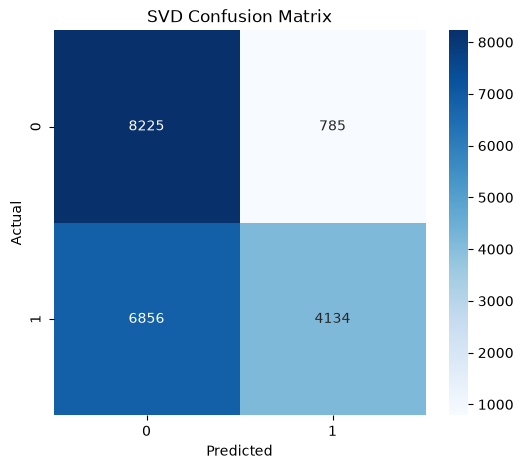

In [51]:
cm_svd = confusion_matrix(
    y_test,
    y_pred_svd
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svd,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVD Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Confusion Matrix: KNN

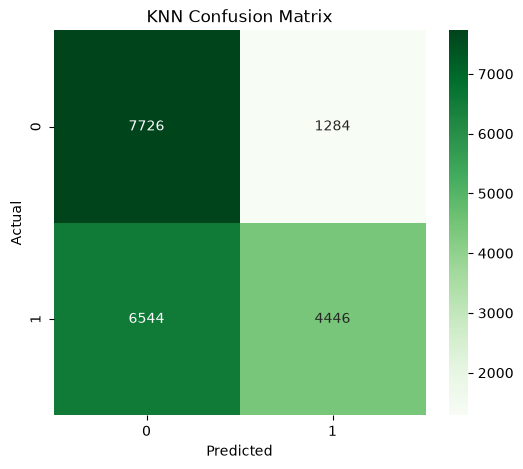

In [52]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### ROC Curves

In [53]:
fpr_svd, tpr_svd, _ = roc_curve(
    y_test,
    svd_predictions
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_predictions
)

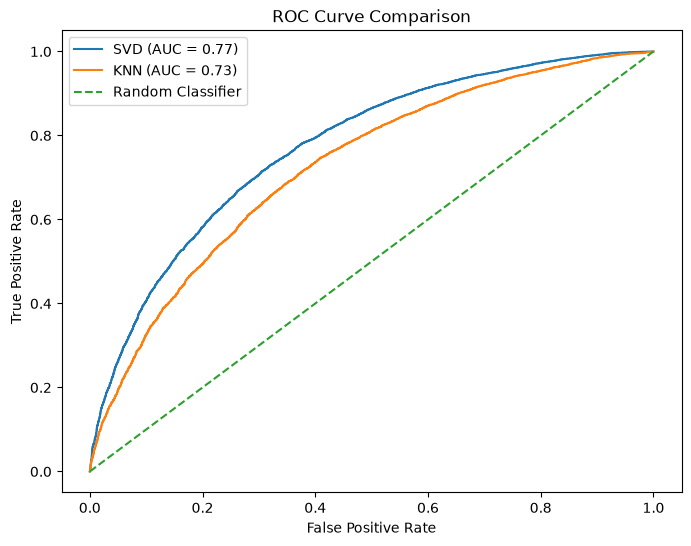

In [54]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_svd,
    tpr_svd,
    label=f'SVD (AUC = {svd_roc:.2f})'
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f'KNN (AUC = {knn_roc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

### Bar Chart Comparison

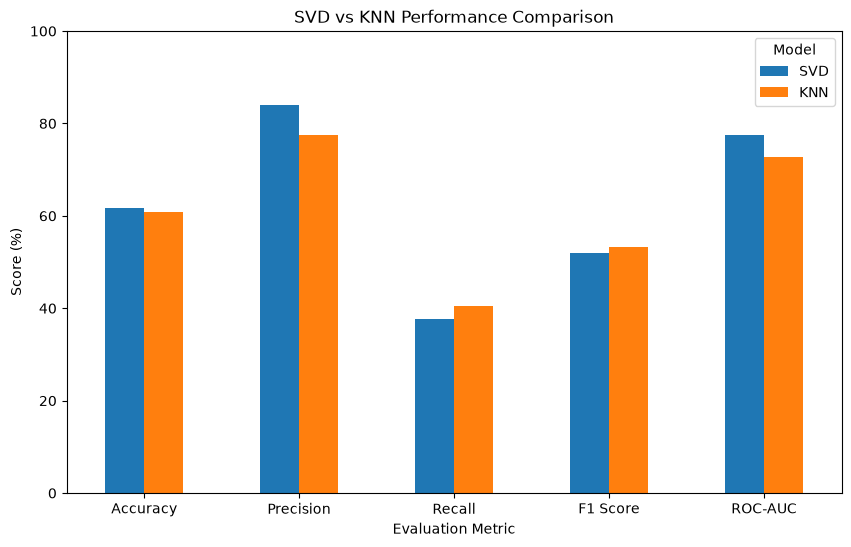

In [55]:
results_plot = results.set_index('Metric')

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('SVD vs KNN Performance Comparison')
plt.ylabel('Score (%)')
plt.xlabel('Evaluation Metric')

plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(title='Model')

plt.show()